In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv("../data/upi_fraud_dataset.csv")

In [3]:
df.head()

,transaction_id,timestamp,hour_of_day,day_of_week,is_weekend,is_night,sender_vpa,sender_bank,sender_state,sender_age_group,...,transaction_status,is_new_payee,sender_txn_count_last_24h,payee_txn_count_last_30d,sender_avg_amount_30d,amount_to_avg_ratio,device_change_flag,sim_change_recent_flag,is_fraud,fraud_type
0,TXNA87D63007ED4,2023-02-07 07:58:12,7,Tuesday,False,False,jalsa.dada3658@oksbi,State Bank of India,West Bengal,26-35,...,SUCCESS,True,3,0,1667.94,0.95,False,False,0,NaN
1,TXN286892C651AC,2023-08-12 01:54:57,1,Saturday,True,True,bachittar.patel9130@barodampay,Bank of Baroda,Maharashtra,26-35,...,SUCCESS,True,4,0,578.30,8.74,False,False,1,Investment Scam
2,TXN63D4351B1603,2023-02-05 15:01:04,15,Sunday,True,False,vritti.tiwari7779@indus,IndusInd Bank,Kerala,60+,...,SUCCESS,False,2,7,656.20,0.83,False,False,0,NaN
3,TXNB7A67F3C596A,2024-03-24 10:56:19,10,Sunday,True,False,azaan.puri783@okaxis,Axis Bank,Andhra Pradesh,26-35,...,SUCCESS,False,3,11,96.13,1.37,False,False,0,NaN
4,TXN35DF03BA1700,2024-05-13 10:42:58,10,Monday,False,False,bhavna.singhal7728@okhdfcbank,HDFC Bank,Kerala,26-35,...,SUCCESS,False,2,4,656.88,0.79,False,False,0,NaN


In [4]:
df.shape

(200000, 29)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   transaction_id             200000 non-null  object 
 1   timestamp                  200000 non-null  object 
 2   hour_of_day                200000 non-null  int64  
 3   day_of_week                200000 non-null  object 
 4   is_weekend                 200000 non-null  bool   
 5   is_night                   200000 non-null  bool   
 6   sender_vpa                 200000 non-null  object 
 7   sender_bank                200000 non-null  object 
 8   sender_state               200000 non-null  object 
 9   sender_age_group           200000 non-null  object 
 10  is_senior_citizen          200000 non-null  bool   
 11  sender_device_type         200000 non-null  object 
 12  receiver_vpa               200000 non-null  object 
 13  receiver_bank              20

In [6]:
df.isnull().sum()

transaction_id                    0
timestamp                         0
hour_of_day                       0
day_of_week                       0
is_weekend                        0
is_night                          0
sender_vpa                        0
sender_bank                       0
sender_state                      0
sender_age_group                  0
is_senior_citizen                 0
sender_device_type                0
receiver_vpa                      0
receiver_bank                     0
transaction_type                  0
merchant_category                 0
payment_app                       0
network_type                      0
amount_inr                        0
transaction_status                0
is_new_payee                      0
sender_txn_count_last_24h         0
payee_txn_count_last_30d          0
sender_avg_amount_30d             0
amount_to_avg_ratio               0
device_change_flag                0
sim_change_recent_flag            0
is_fraud                    

In [7]:
df["is_fraud"].value_counts()

is_fraud
0    193600
1      6400
Name: count, dtype: int64

In [8]:
df.groupby("is_fraud")["fraud_type"].count()

is_fraud
0       0
1    6400
Name: fraud_type, dtype: int64

In [9]:
df.groupby("hour_of_day")["is_fraud"].mean()

hour_of_day
0     0.078990
1     0.078504
2     0.083315
3     0.083673
4     0.079780
5     0.014244
6     0.014627
7     0.014778
8     0.015281
9     0.013592
10    0.012737
11    0.017447
12    0.014661
13    0.012680
14    0.016163
15    0.011966
16    0.017810
17    0.015728
18    0.014284
19    0.015942
20    0.013576
21    0.014510
22    0.014893
23    0.078481
Name: is_fraud, dtype: float64

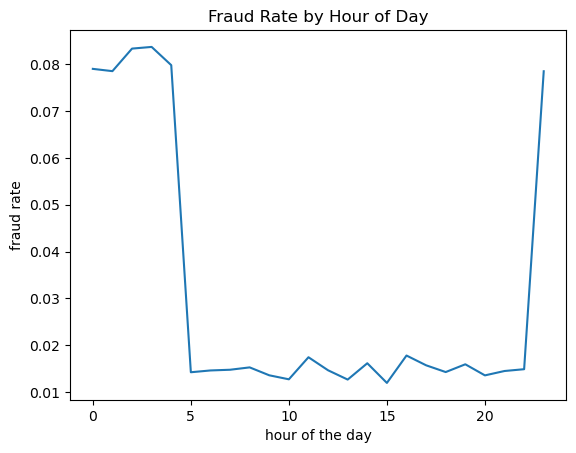

In [10]:
df.groupby("hour_of_day")["is_fraud"].mean().plot(kind="line")
plt.ylabel("fraud rate")
plt.xlabel("hour of the day")
plt.title("Fraud Rate by Hour of Day")
plt.show()

In [11]:
df.groupby("is_night")["is_fraud"].mean()

is_night
False    0.014714
True     0.080448
Name: is_fraud, dtype: float64

In [12]:
df.groupby("merchant_category")["is_fraud"].count()

merchant_category
Bill Payment          10554
DTH/Cable              1147
Education              5460
Entertainment          7627
Food Delivery         11549
Fuel                   8254
Gaming                 3923
Grocery               14569
Healthcare             6565
Insurance               932
Investment             5296
Mobile Recharge        9858
P2P Transfer          90596
Rent                   3052
Shopping              11801
Travel & Transport     8817
Name: is_fraud, dtype: int64

In [13]:
result=df.groupby("merchant_category")["is_fraud"].aggregate(["count","mean"])

In [14]:
result=result.rename(columns={
    "count":"transaction count",
    "mean":"fraud rate"
})

In [15]:
result

,transaction count,fraud rate
merchant_category,,
Bill Payment,10554,0.022172
DTH/Cable,1147,0.026155
Education,5460,0.021795
Entertainment,7627,0.022683
Food Delivery,11549,0.021647
Fuel,8254,0.019506
Gaming,3923,0.144532
Grocery,14569,0.021072
Healthcare,6565,0.022391


In [16]:
result.sort_values("fraud rate",ascending=False)

,transaction count,fraud rate
merchant_category,,
Gaming,3923,0.144532
Investment,5296,0.114426
Travel & Transport,8817,0.078258
P2P Transfer,90596,0.027794
DTH/Cable,1147,0.026155
Mobile Recharge,9858,0.025360
Insurance,932,0.023605
Entertainment,7627,0.022683
Healthcare,6565,0.022391


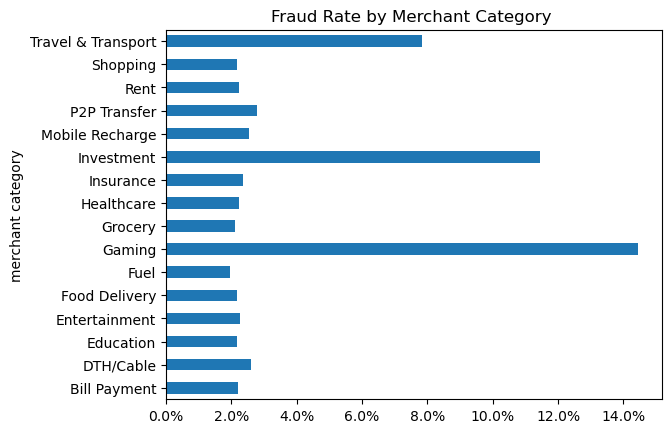

In [17]:
from matplotlib.ticker import PercentFormatter
result["fraud rate"].plot(kind="barh")
plt.ylabel("merchant category")
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.title("Fraud Rate by Merchant Category ")
plt.show()

In [18]:
type=df.groupby("transaction_type")["is_fraud"].mean().sort_values(ascending=False)

In [19]:
type

transaction_type
P2M    0.035483
P2P    0.027794
Name: is_fraud, dtype: float64

In [20]:
df["transaction_type"].value_counts()

transaction_type
P2M    109404
P2P     90596
Name: count, dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   transaction_id             200000 non-null  object 
 1   timestamp                  200000 non-null  object 
 2   hour_of_day                200000 non-null  int64  
 3   day_of_week                200000 non-null  object 
 4   is_weekend                 200000 non-null  bool   
 5   is_night                   200000 non-null  bool   
 6   sender_vpa                 200000 non-null  object 
 7   sender_bank                200000 non-null  object 
 8   sender_state               200000 non-null  object 
 9   sender_age_group           200000 non-null  object 
 10  is_senior_citizen          200000 non-null  bool   
 11  sender_device_type         200000 non-null  object 
 12  receiver_vpa               200000 non-null  object 
 13  receiver_bank              20

In [22]:
df.groupby("sender_device_type")["is_fraud"].mean().sort_values(ascending=False)

sender_device_type
iOS        0.032538
Android    0.031458
Name: is_fraud, dtype: float64

In [23]:
df.groupby("device_change_flag")["is_fraud"].mean()

device_change_flag
False    0.017529
True     0.261728
Name: is_fraud, dtype: float64

In [24]:
df.groupby("sim_change_recent_flag")["is_fraud"].mean()

sim_change_recent_flag
False    0.025565
True     0.417098
Name: is_fraud, dtype: float64

In [25]:
df.groupby("is_new_payee")["is_fraud"].mean()

is_new_payee
False    0.008843
True     0.059061
Name: is_fraud, dtype: float64

In [26]:
bins = [0, 500, 1000, 5000, 10000, 25000, float("inf")]
labels = ["0-500", "500-1K", "1K-5K", "5K-10K", "10K-25K", "25K+"]

In [27]:
df["amount_range"]=pd.cut(
    df["amount_inr"],
    labels=labels,
    bins=bins
)

In [29]:
df.groupby("amount_range")["is_fraud"].mean()

C:\Users\user\AppData\Local\Temp\ipykernel_1224\3445504775.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("amount_range")["is_fraud"].mean()


amount_range
0-500      0.032536
500-1K     0.003218
1K-5K      0.020524
5K-10K     0.140851
10K-25K    0.436310
25K+       0.797565
Name: is_fraud, dtype: float64

In [28]:
df.groupby("is_fraud")["amount_inr"].mean()

is_fraud
0    1327.390291
1    8356.359073
Name: amount_inr, dtype: float64

In [34]:
txn_bins = [0, 1, 3, 5, 10, float("inf")]

txn_labels = ["0-1", "2-3", "4-5", "6-10", "10+"]

In [35]:
df["sender_count"] = pd.cut(
    df["sender_txn_count_last_24h"],
    bins=txn_bins,
    labels=txn_labels
)

In [36]:
df["sender_count"].value_counts().sort_index()

sender_count
0-1     53342
2-3     88743
4-5     24763
6-10     4337
10+      2380
Name: count, dtype: int64

In [37]:
df.groupby("sender_count")["is_fraud"].mean()

C:\Users\user\AppData\Local\Temp\ipykernel_1224\3127034616.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sender_count")["is_fraud"].mean()


sender_count
0-1     0.015054
2-3     0.014672
4-5     0.015184
6-10    0.272308
10+     0.998319
Name: is_fraud, dtype: float64

In [38]:
df["amount_to_avg_ratio"].describe()

count    200000.000000
mean          1.380505
std           2.156158
min           0.000000
25%           0.690000
50%           1.010000
75%           1.490000
max          86.440000
Name: amount_to_avg_ratio, dtype: float64

In [39]:
ratio_bins = [0, 1, 2, 5, 10, float("inf")]

ratio_labels = ["0-1x", "1-2x", "2-5x", "5-10x", "10x+"]

df["ratio_range"] = pd.cut(
    df["amount_to_avg_ratio"],
    bins=ratio_bins,
    labels=ratio_labels
)

In [40]:
df.groupby("ratio_range")["is_fraud"].mean()

C:\Users\user\AppData\Local\Temp\ipykernel_1224\2629442571.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ratio_range")["is_fraud"].mean()


ratio_range
0-1x     0.014145
1-2x     0.002291
2-5x     0.038956
5-10x    0.787631
10x+     0.999496
Name: is_fraud, dtype: float64

In [42]:
df["ratio_range"].value_counts().sort_index()

ratio_range
0-1x     98833
1-2x     76387
2-5x     20382
5-10x     1714
10x+      1986
Name: count, dtype: int64

In [44]:
corr = df.corr(numeric_only=True)

In [ ]:
sns.heatmap(corr, annot=True)